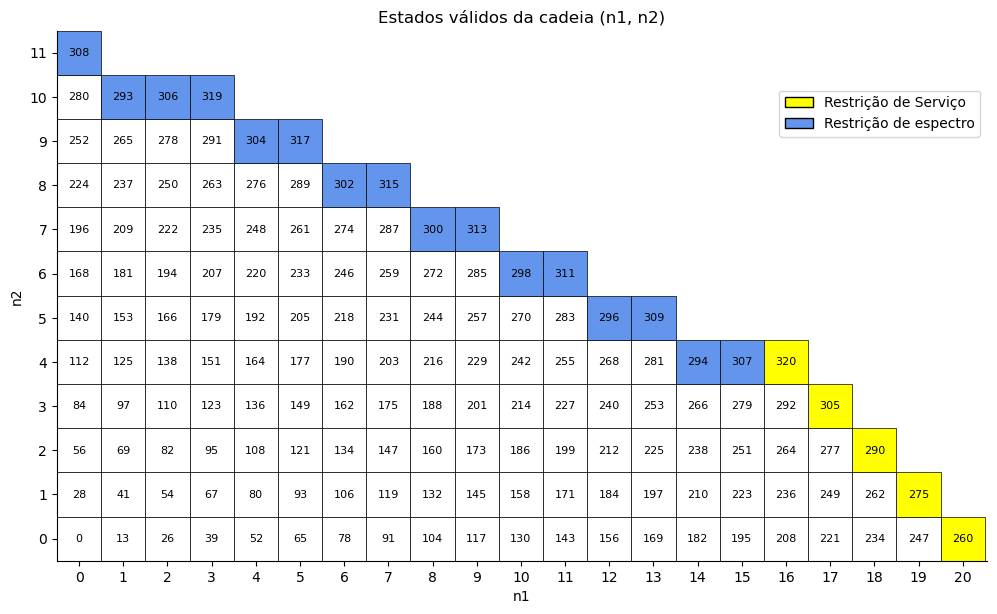

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch

# Parâmetros
b1 = 13
b2 = 28
S = 320
M = 20

# Descobrir quais estados (n1,n2) são válidas
estados = []

for n2 in range(M+1):
    for n1 in range(M+1):
        if n1 + n2 <= M and b1*n1 + b2*n2 <= S:
            estados.append((n1, n2))

# Criar figura
fig, ax = plt.subplots(figsize = (12,8)) # ax = sistema de eixos (plano cartesiano)

# Representação dos estados (n1,n2)
for n1,n2 in estados:
    valor = b1*n1 + b2*n2
    cap_max_fonte = (n1+n2 == M)

    # Restrição de espectro
    restricao = (
        b1*(n1+1) + b2*n2 > S
        or
        b1*n1 + b2*(n2+1) > S
    )
    
    rect = patches.Rectangle( 
        (n1 - 0.5, n2 - 0.5), # posição
        1, # tamanho
        1, # tamanho
        linewidth = 0.5, # grossura da borda
        edgecolor = "black", # borda
        facecolor = ("yellow" if cap_max_fonte
                     else "#6495ED" if restricao
                     else "white")
    )
    
    ax.add_patch(rect) # Adicionar o quadrado na figura "fig, ax"

    #texto
    ax.text(
        n1,
        n2,
        valor, # resultados dos valores de n1 e n2 válidos
        ha = "center", # centralizando na horizontal (alinhamento)
        va = "center", # centralizando na vertical (alinhamento)
        fontsize = 8 # Tamanho da fonte
    )

# Configuração dos eixos
n1_validos = [n1 for n1,n2 in estados] # Pegando os valores válidos de n1 e n2 
n2_validos = [n2 for n1,n2 in estados]

ax.set_xticks(sorted(set(n1_validos))) # Adicionando os estados de n1
ax.set_yticks(sorted(set(n2_validos))) # Adicionado os estodas de n2
                                       # set() remove os numeros duplicados e sorted() deixa os valores em ordem crecente

#titulo dos eixos x e y
ax.set_xlabel("n1")
ax.set_ylabel("n2")

# Ajustando os limites do gráfico
ax.set_xlim(-0.5, max(n1_validos)+0.55)
ax.set_ylim(-0.5, max(n2_validos)+0.5)

# remover bordas superiores
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Manter a proporção correta
ax.set_aspect("equal")

legenda = [
    Patch(facecolor = "yellow", edgecolor = "black", label = "Restrição de Serviço" ),
    Patch(facecolor = "#6495ED", edgecolor = "black", label = "Restrição de espectro")
    ]

ax.legend(
    handles = legenda,
    loc = "upper right",
    bbox_to_anchor = (1,0.9),
    fontsize = 10,
    frameon = True
)

# Título
plt.title("Estados válidos da cadeia (n1, n2)")

# Salvando a imagem em pdf
#fig.savefig(
#    "Estados válidos da cadeia (n1, n2).pdf",
#    dpi = 600,
#    bbox_inches = "tight",
#    facecolor = "white"
#    
#)

plt.show()


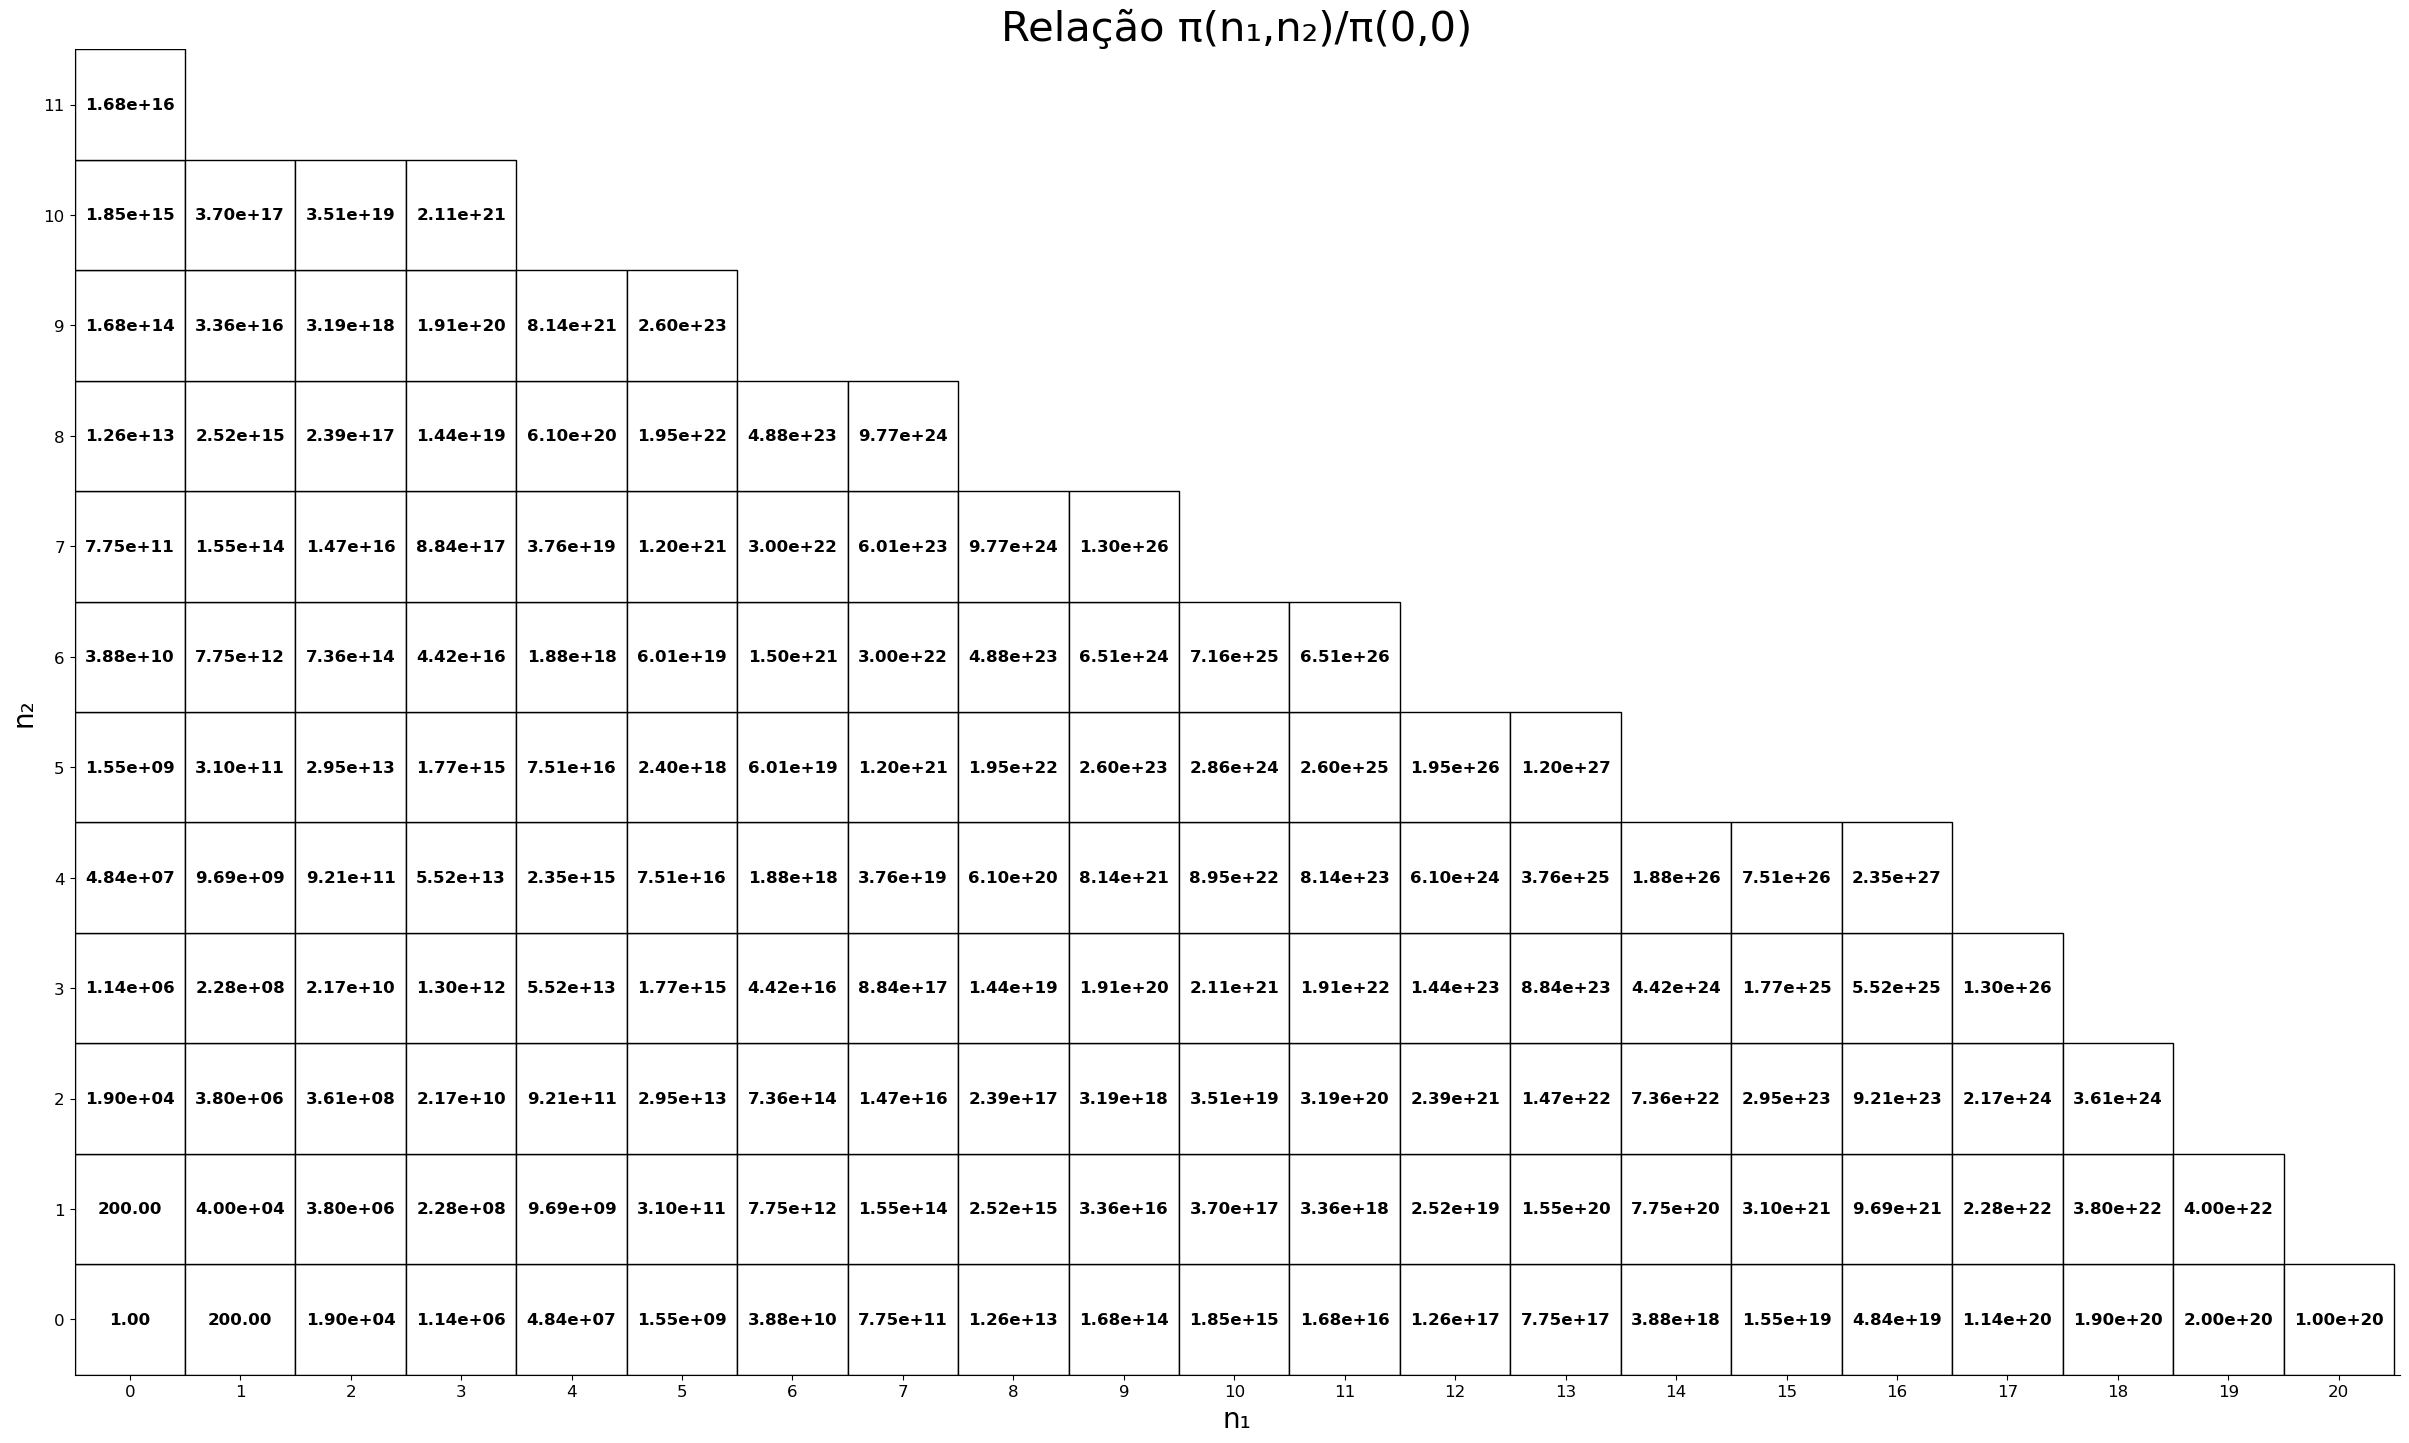

Denominador de π(n₁,n₂): 5.8536e+27


In [2]:
from math import comb

# Parâmetros
b1 = 13
b2 = 28
S = 320
M = 20
rho = 20
gamma1 = gamma2 = 0.5

# Espaço de estados χg e a Relação π(n1,n2)/π(0,0)
estados = []
relacao = {}

for n2 in range(M + 1):
    for n1 in range(M + 1):
        if n1 + n2 <= M and b1 * n1 + b2 * n2 <= S:
            estados.append((n1, n2))
            for n1, n2 in estados: # Cálculo da relação π(n1,n2)/π(0,0)
                relacao[(n1, n2)] = (rho * gamma1) ** n1 * (rho * gamma2) ** n2 * comb(M, n1) * comb(M, n2)

# Tabela gráfica
fig, ax = plt.subplots(figsize=(30, 18))

# Representação dos estados (n1,n2)
for n1, n2 in estados:
    rect = patches.Rectangle( 
        (n1 - 0.5, n2 - 0.5), # posição
        1, # tamanho
        1, # tamanho
        linewidth=1, # grossura das linhas
        edgecolor='black', # borda
        facecolor='white' # cor      
    )

    ax.add_patch(rect)

    # Formatação resultado
    R = relacao[(n1, n2)]
    
    if R < 10000:
        texto = f"{R:.2f}"
    else:
        texto = f"{R:.2e}"

    # Configurações de texto
    ax.text(
        n1,
        n2,
        texto,
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold' if (n1+n2==M)  else 'black'    
    )

#titulo dos eixos x e y
ax.set_xlabel("n₁", fontsize=20)
ax.set_ylabel("n₂", fontsize=20)

# Configuração dos eixos
ax.set_xticks(sorted(set(n1_validos)))
ax.set_yticks(sorted(set(n2_validos)))

# Tamanho dos números dos eixos
ax.tick_params(axis='both', labelsize=12)

# Ajustando os limites do gráfico
ax.set_xlim(-0.5, max(n1_validos) + 0.55)
ax.set_ylim(-0.5, max(n2_validos) + 0.5)

# Manter a proporção correta
ax.set_aspect('equal')

# remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Título
plt.title("Relação π(n₁,n₂)/π(0,0)", fontsize=30)

# Salvando a imagem em pdf (opcional)
#fig.savefig(
#    "Relação π(n₁,n₂) dividido por π(0,0).pdf",
#    dpi = 600,
#    bbox_inches = "tight",
#    facecolor = "white"
#)

plt.show()

# Denominador da Eq. (9): π(n₁,n₂)
eq9 = sum(relacao.values())
print(f"Denominador de π(n₁,n₂): {eq9:.4e}")


Soma das probabilidades = 1.000000000000
Psc: 0.423841809379

Estados que compõem a restrição de serviço:
(20, 0) -> 1.708342e-08
(19, 1) -> 6.833368e-06
(18, 2) -> 6.167115e-04
(17, 3) -> 2.220161e-02
(16, 4) -> 4.010166e-01


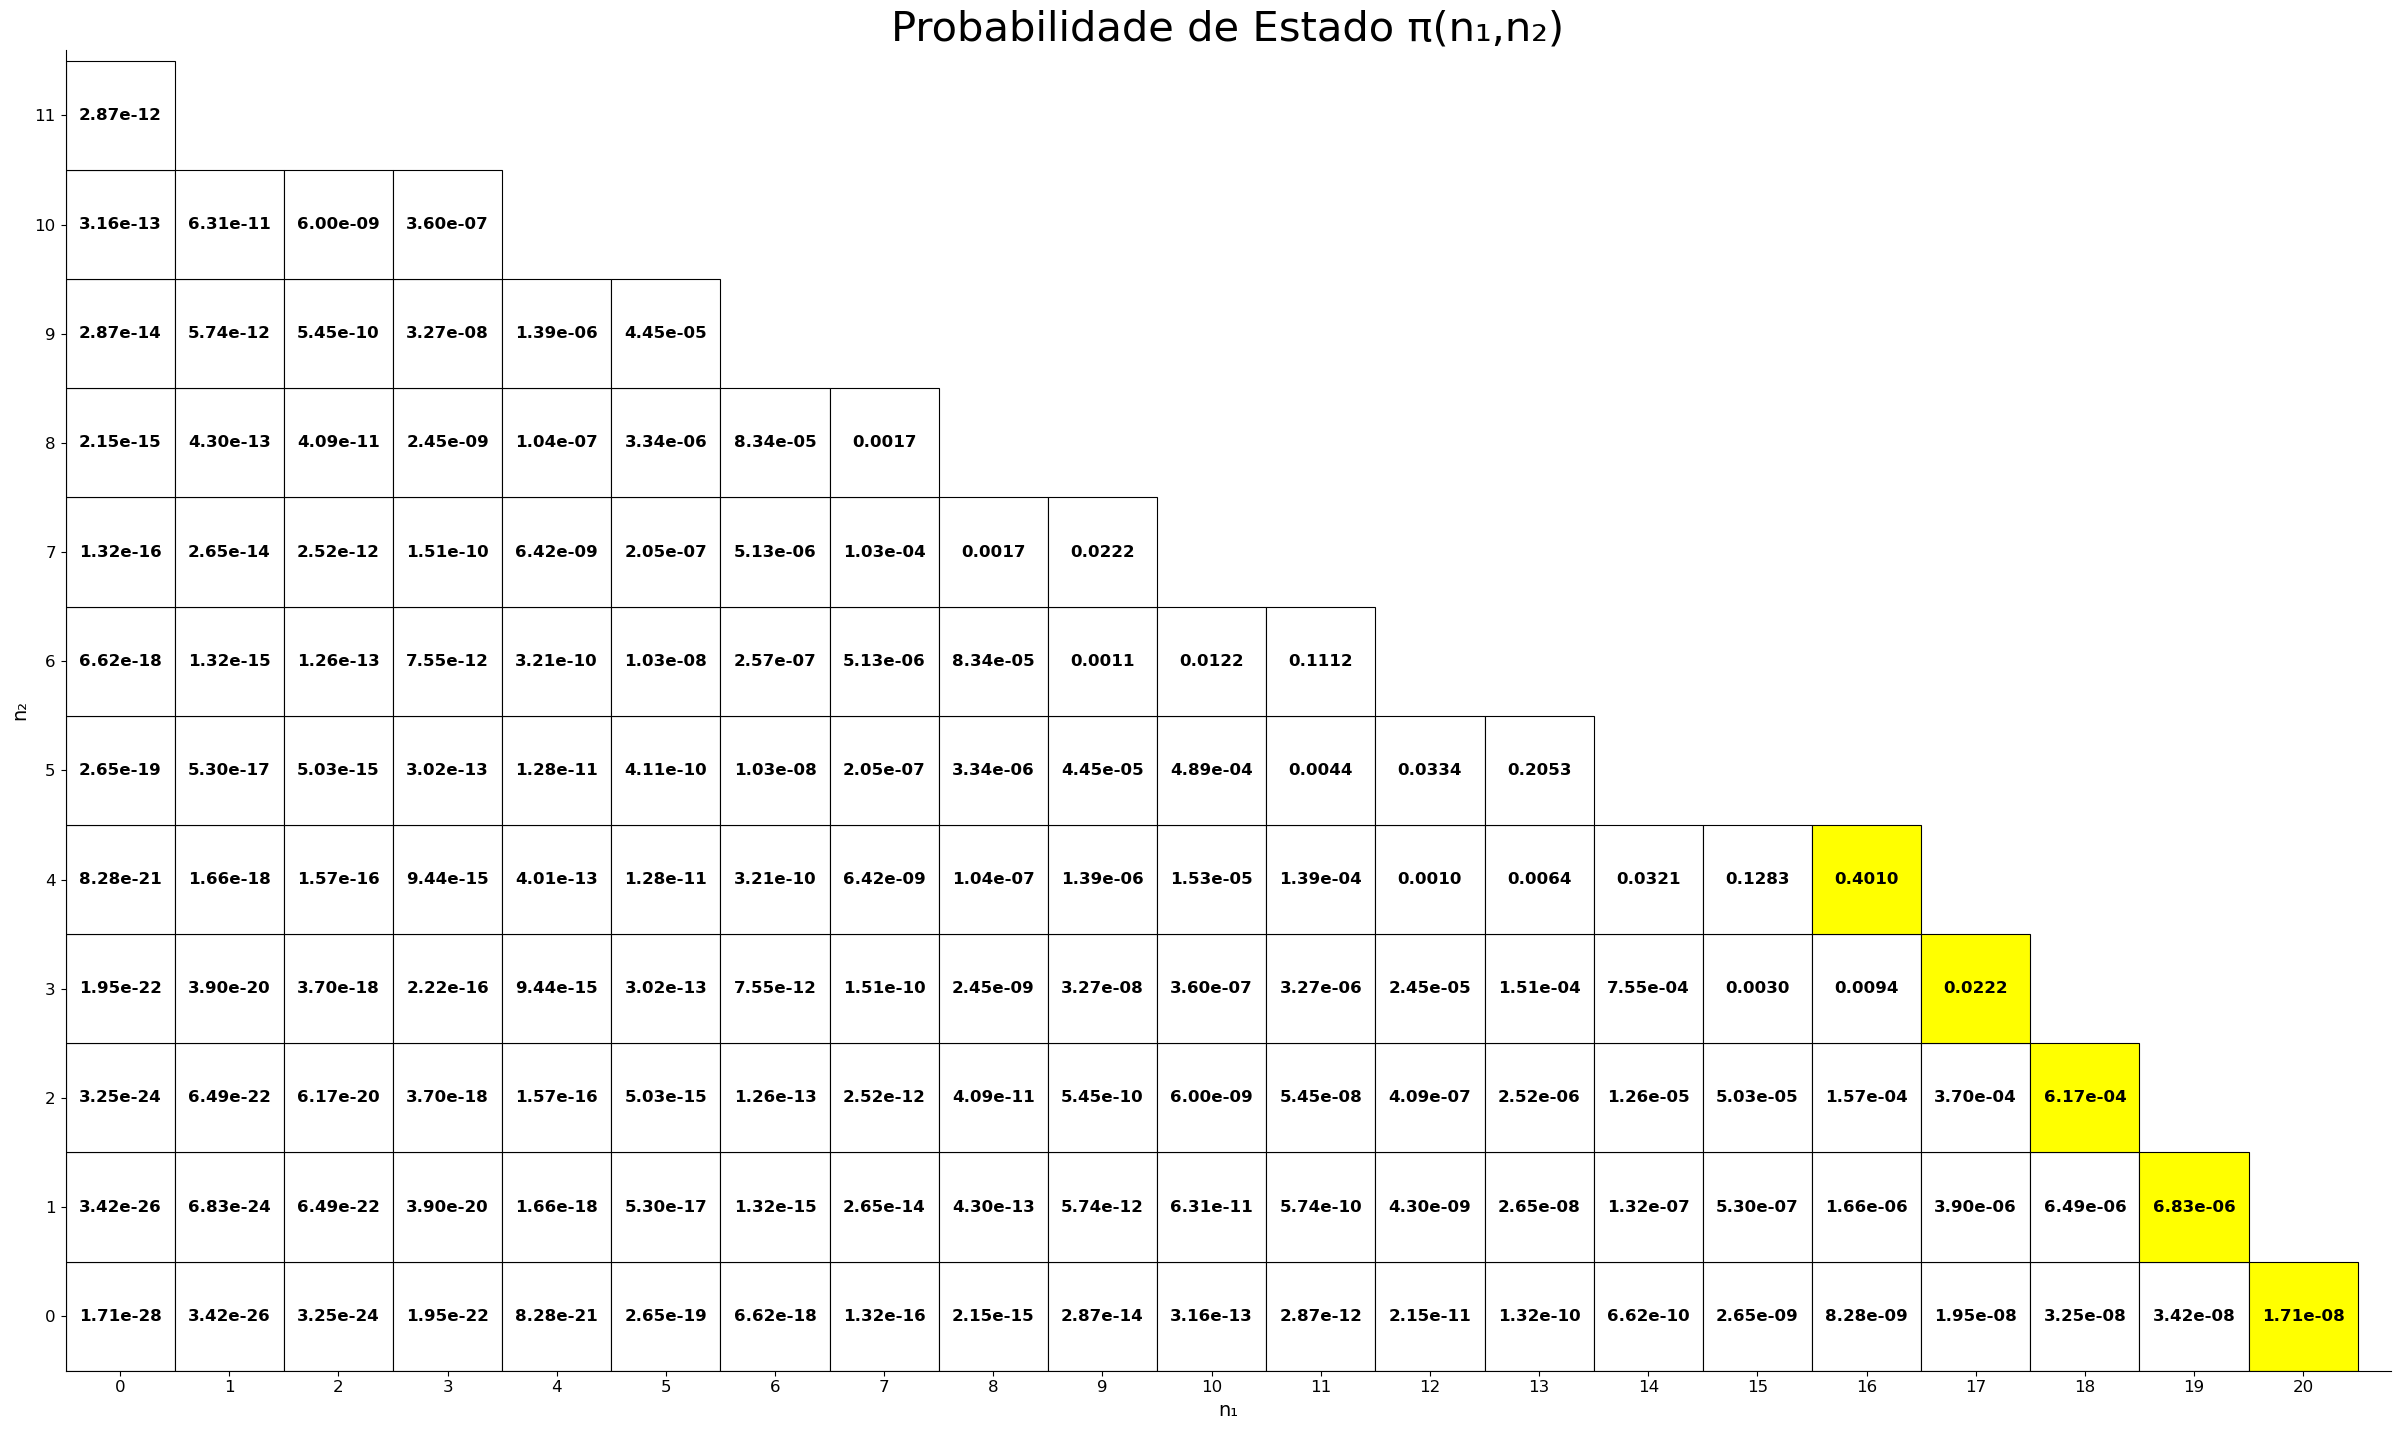

In [5]:
# Probabilidade de cada estado (n1,n2)
prob_estado = {}

for cada_estado in estados:
    prob_estado[cada_estado] = (relacao[cada_estado] / eq9)

# Probabilidade de restrição de serviço 
Psc = sum(
    prob_estado[(n1, n2)]
    for n1, n2 in estados
    if n1 + n2 == M
)

# Tabela gráfica
fig, ax = plt.subplots(figsize=(30, 18))

for n1, n2 in estados:
    cap_max_fonte = (n1+n2 == M)
    
    rect = patches.Rectangle(
        (n1 - 0.5, n2 - 0.5), # posição
        1, # tamanho
        1, # tamanho
        linewidth=0.8, # grossura das linhas
        edgecolor='black', # cor
        facecolor="yellow" if cap_max_fonte else 'white'
    )

    ax.add_patch(rect)

    # Formatação texto
    if  prob_estado[(n1, n2)] >= 1e-3:
        texto = f"{prob_estado[(n1, n2)]:.4f}"
    else:
        texto = f"{prob_estado[(n1, n2)]:.2e}"

    ax.text(
        n1,
        n2,
        texto,
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold' if n1+n2==M else "black"
    )

# Configuração dos eixos
ax.set_xlabel("n₁", fontsize=14)
ax.set_ylabel("n₂", fontsize=14)

ax.set_xticks(sorted(set(n1_validos)))
ax.set_yticks(sorted(set(n2_validos)))

ax.tick_params(axis='both',labelsize=12)

ax.set_xlim(-0.5, max(n1_validos) + 0.8)
ax.set_ylim(-0.5,max(n2_validos) + 0.6)

ax.set_aspect('equal')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#Título
plt.title("Probabilidade de Estado π(n₁,n₂)", fontsize=30)

#Salvando a imagem em pdf (opcional)
#fig.savefig(
#    "Probabilidade de Estado π(n₁,n₂).pdf",
#    dpi = 600,
#    bbox_inches = "tight",
#    facecolor = "white"
#)

# Resultados
print(f"Soma das probabilidades = {sum(prob_estado.values()):.12f}")
print(f"Psc: {Psc:.12f}")
print("\nEstados que compõem a restrição de serviço:")

for n1, n2 in estados:
    if n1 + n2 == M:
        print(
            f"({n1},{n2:2d}) -> " # {n2:2d} da espaço com o 2d
            f"{prob_estado[(n1,n2)]:.6e}"
        )


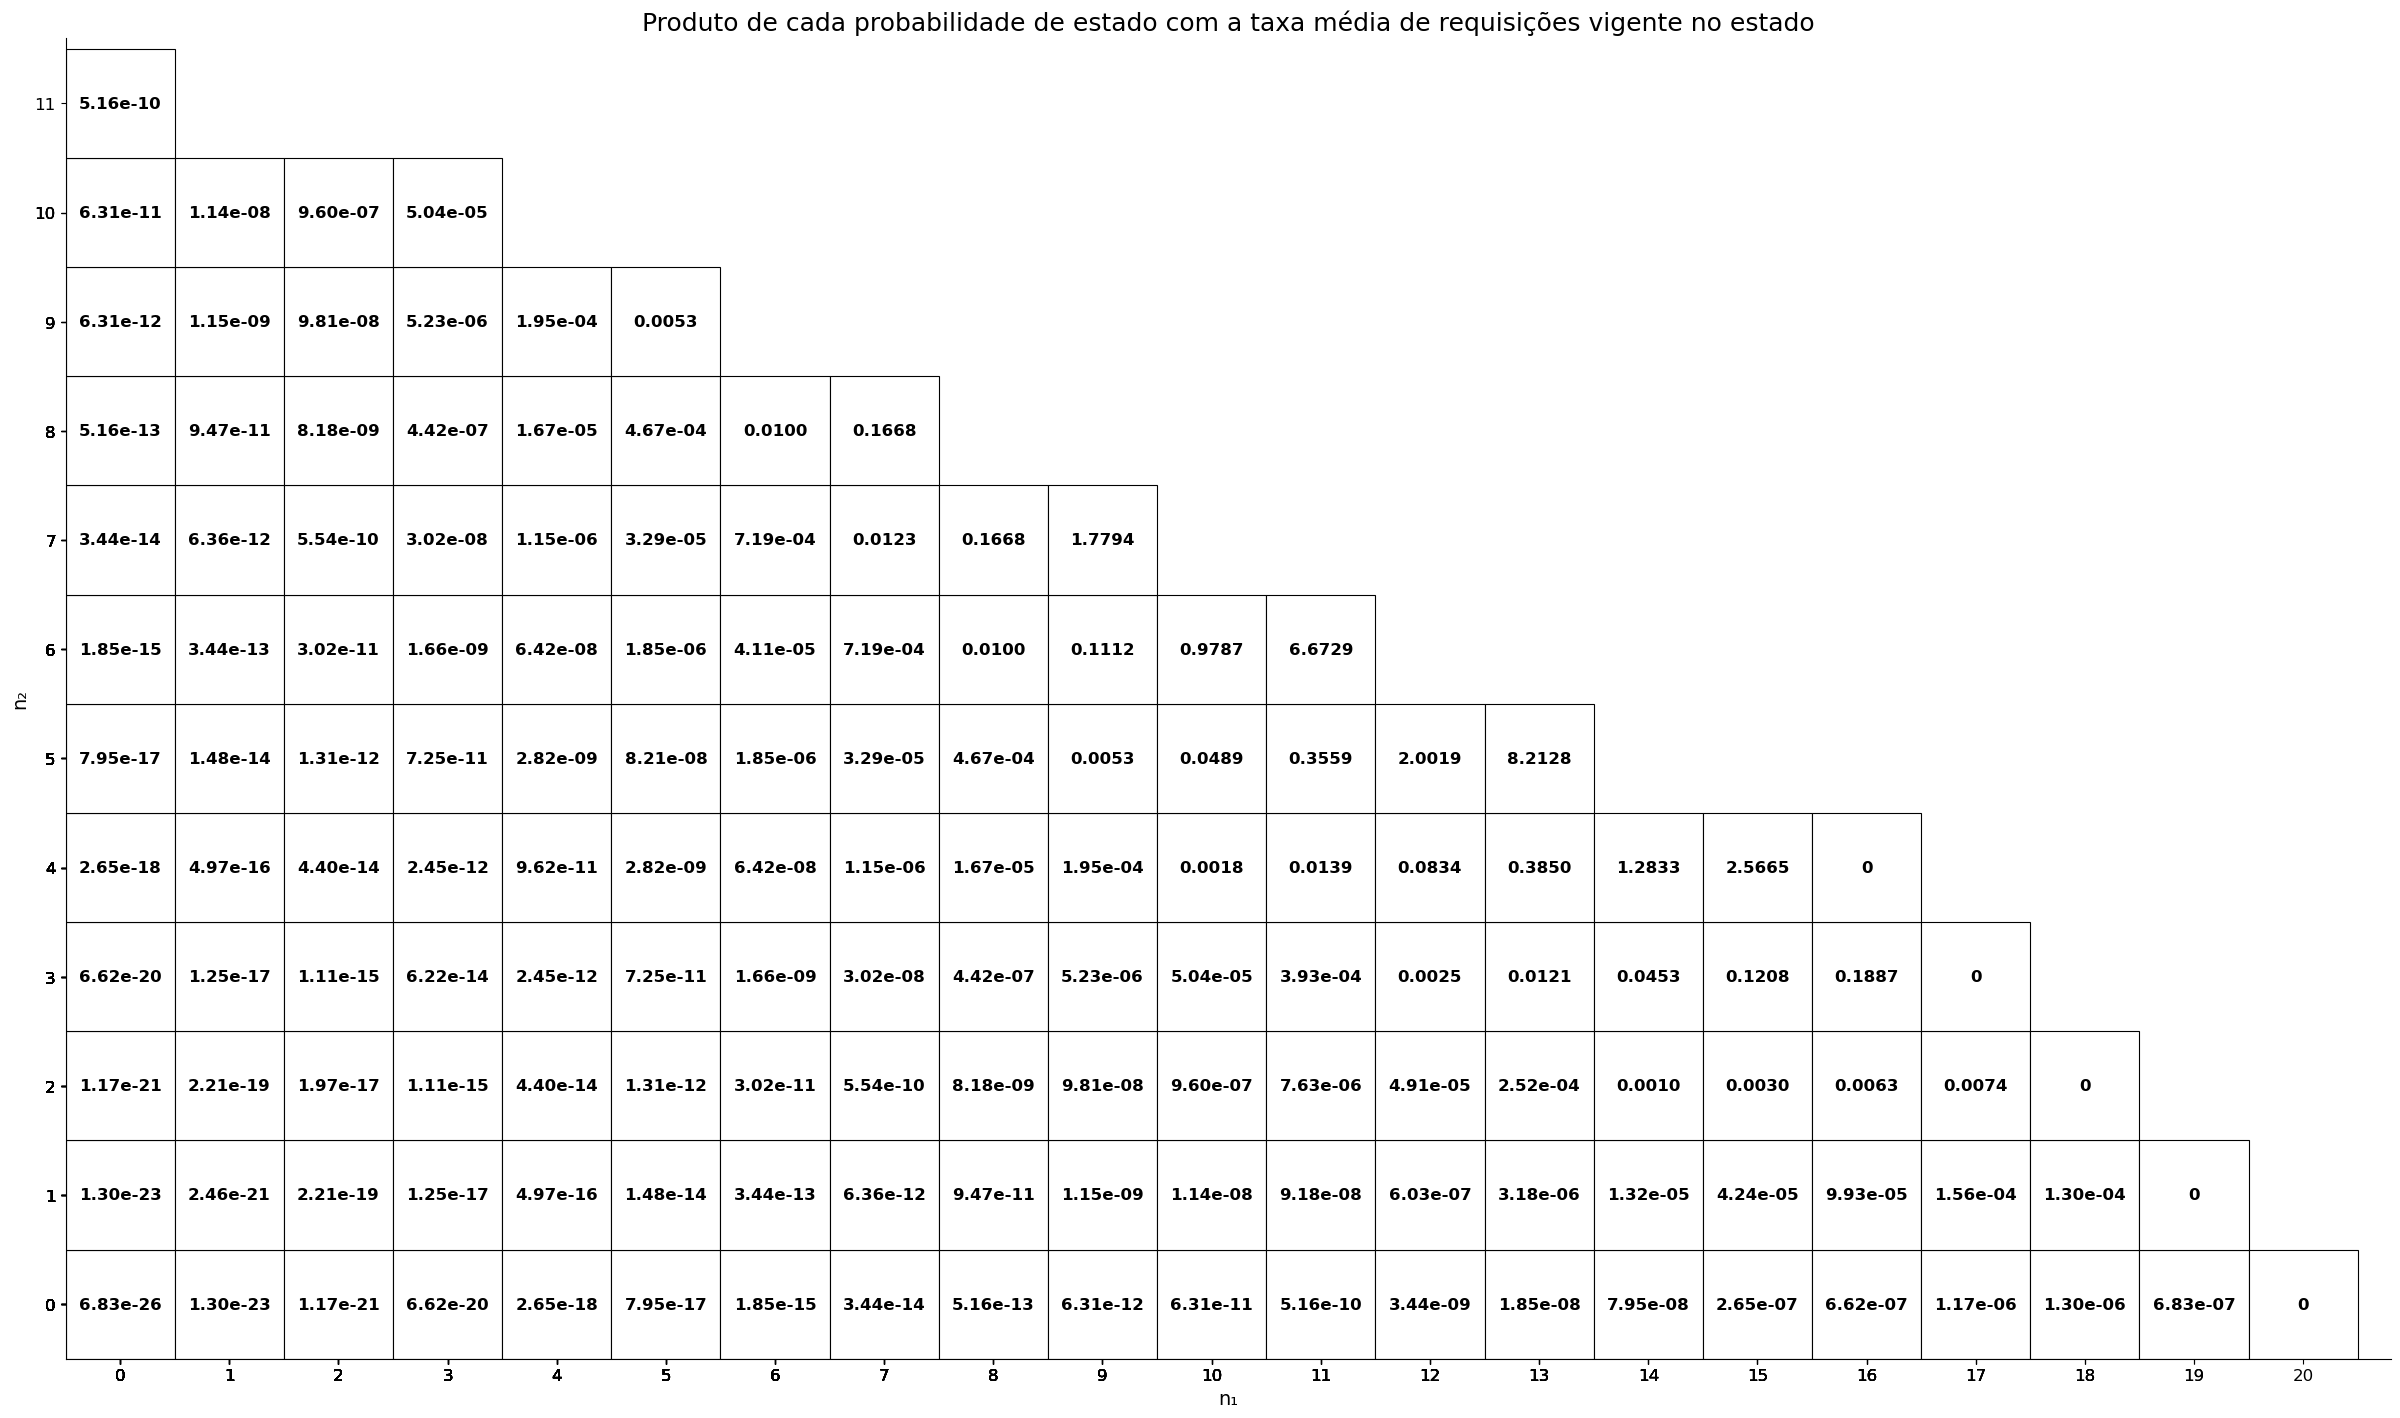

TAXA MÉDIA DE REQUISIÇÕES
λ = Σ(M-n₁-n₂)ρπ(n₁,n₂) = 25.263535392478


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from math import comb

# Produto: (M-n1-n2)ρπ(n1,n2)
produto_estado = {}

for n1, n2 in estados:
    produto_estado[(n1, n2)] = (
        (M - n1 - n2)
        * rho
        * prob_estado[(n1, n2)]
    )

# λ
lambda_total = sum(produto_estado.values())

# Figura
fig, ax = plt.subplots(figsize=(30, 18))

for n1, n2 in estados:
    cap_max_fonte = (n1 + n2 == M)

    rect = patches.Rectangle(
        (n1 - 0.5, n2 - 0.5),
        1,
        1,
        linewidth=0.8,
        edgecolor='black',
        facecolor='white'
    )

    ax.add_patch(rect)

    valor = produto_estado[(n1, n2)]

    # Formatação do texto

    if valor == 0:
        texto = "0"

    elif valor >= 1e-3:
        texto = f"{valor:.4f}"

    else:
        texto = f"{valor:.2e}"

    ax.text(
        n1,
        n2,
        texto,
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold'
    )

# Configuração dos eixos
ax.set_xlabel("n₁", fontsize=14)
ax.set_ylabel("n₂", fontsize=14)

ax.set_xticks(n1_validos)
ax.set_yticks(n2_validos)

ax.tick_params(axis='both',labelsize=12)

ax.set_xlim(-0.5,max(n1_validos) + 0.8)
ax.set_ylim(-0.5,max(n2_validos) + 0.6)

ax.set_aspect('equal')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title(r'Produto de cada probabilidade de estado com a taxa média de requisições vigente no estado',fontsize=18)

#fig.savefig(
#    "Produto de cada probabilidade de estado com a taxa média de requisições vigente no estado.pdf",
#    dpi=600,
#    bbox_inches = "tight",
#    facecolor = "white"
#)

plt.show()

# Resultados
print("TAXA MÉDIA DE REQUISIÇÕES")
print(f"λ = Σ(M-n₁-n₂)ρπ(n₁,n₂) = {lambda_total:.12f}")


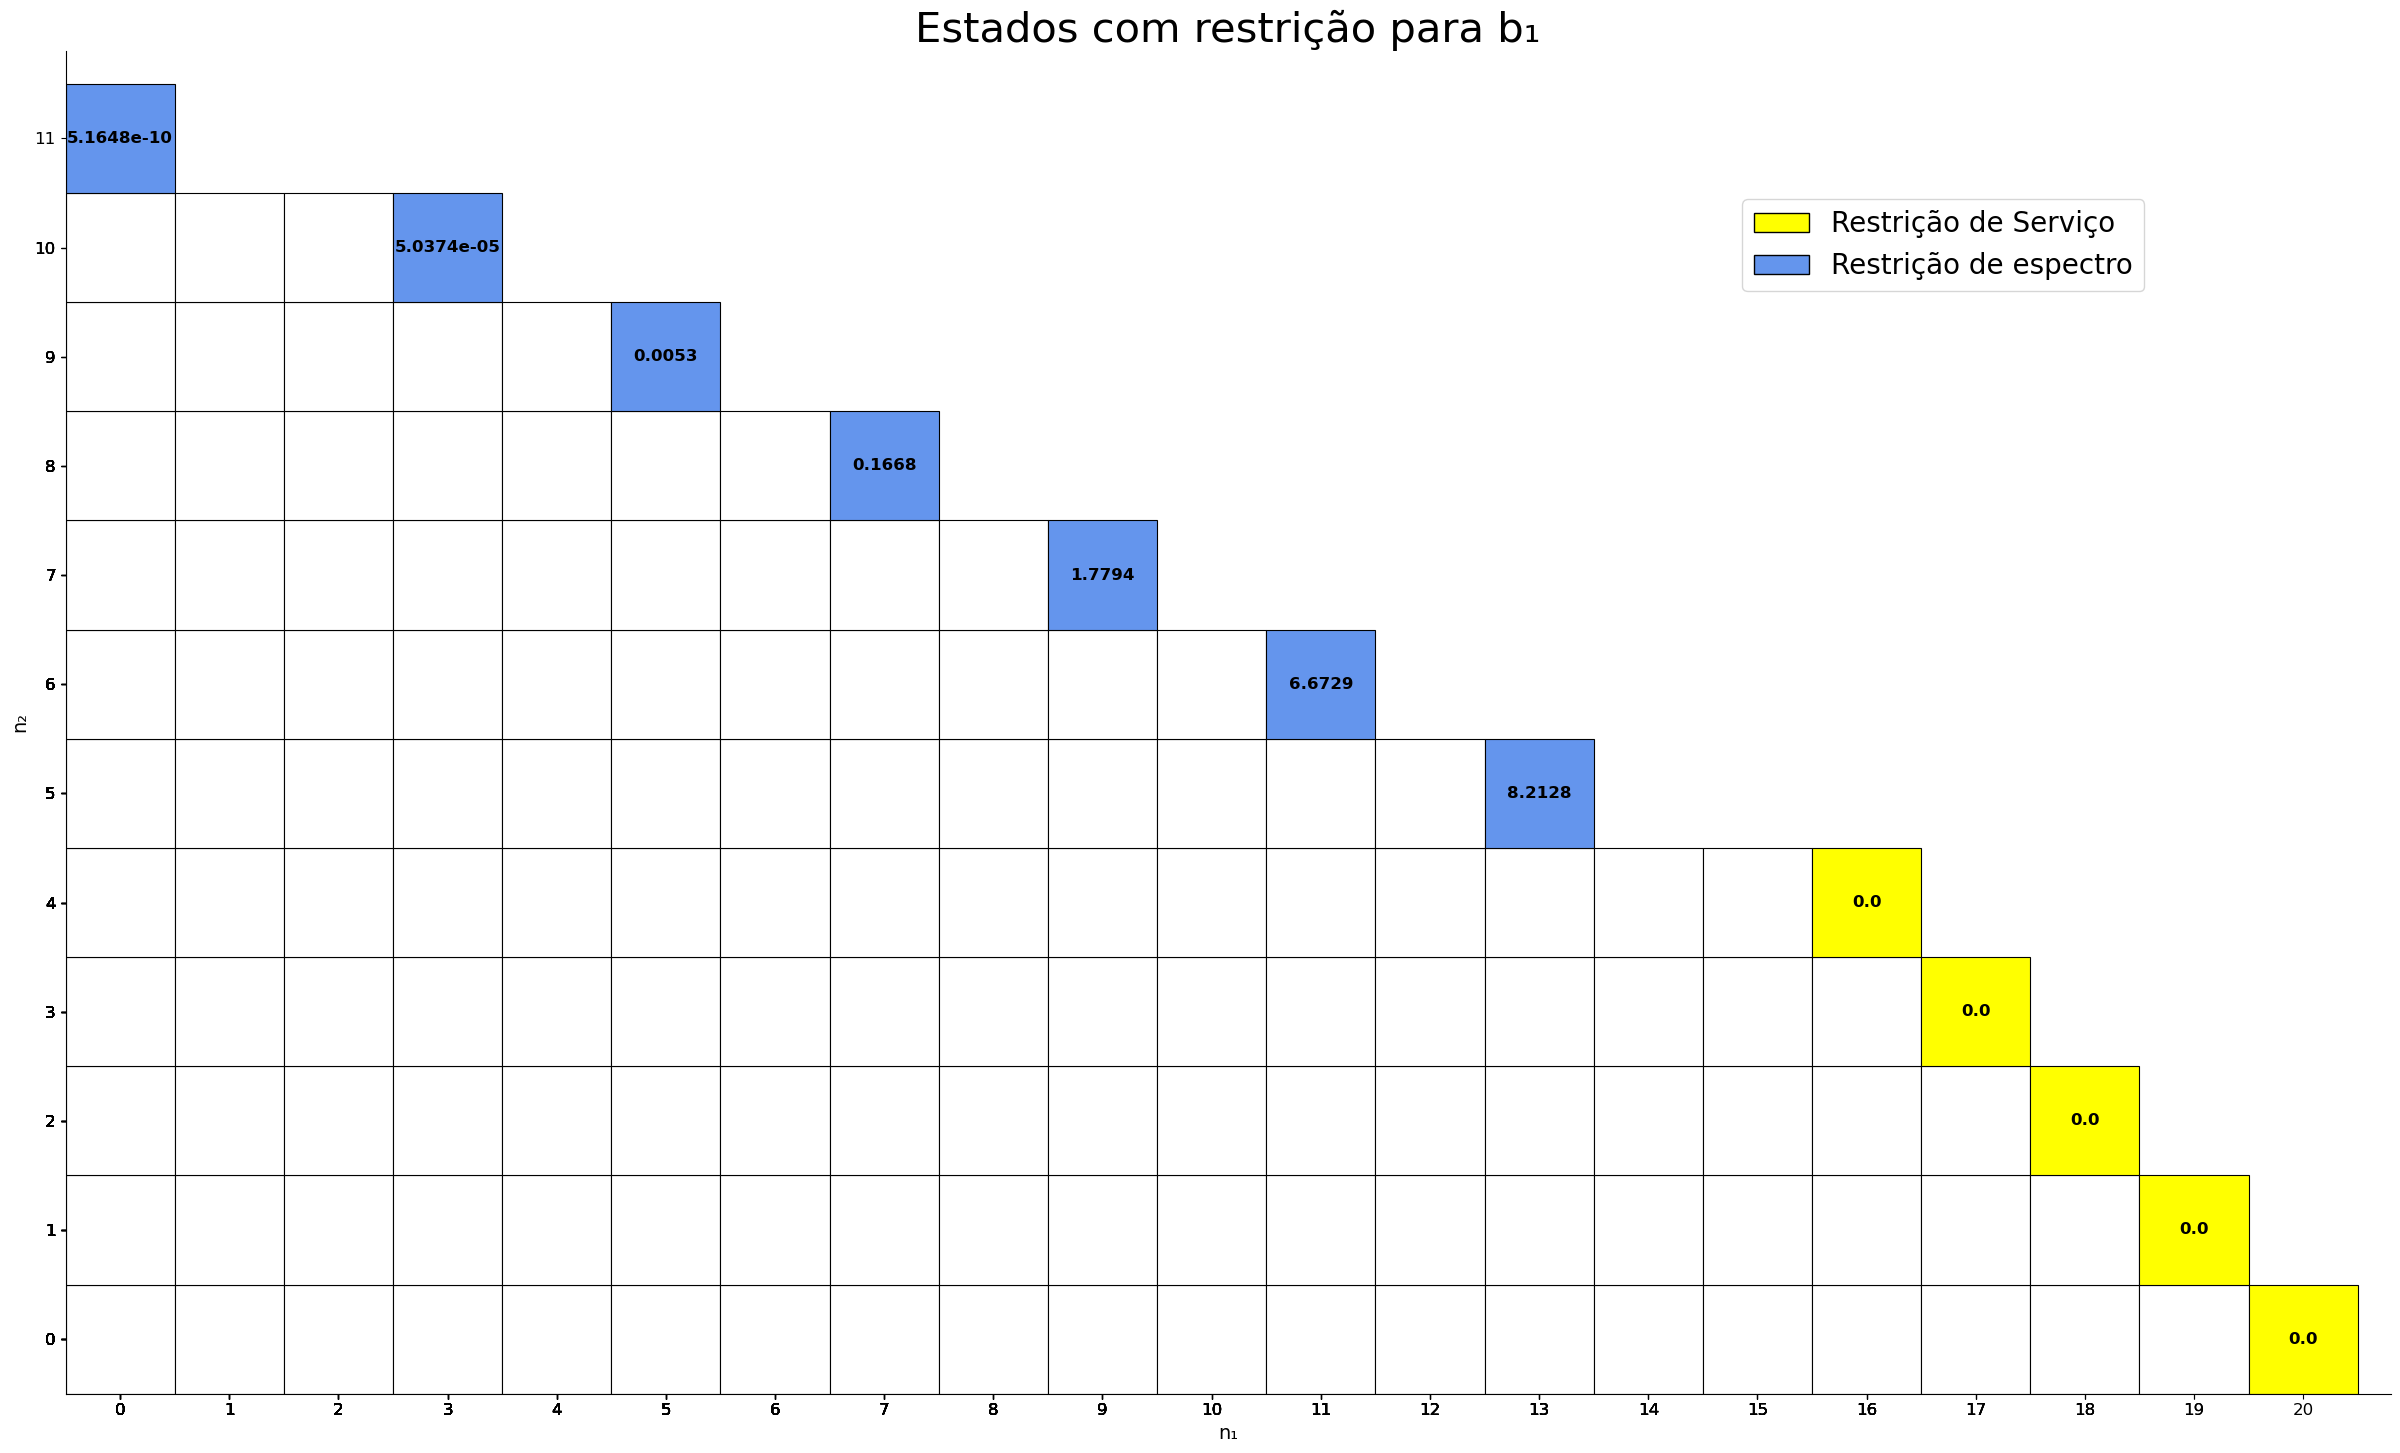

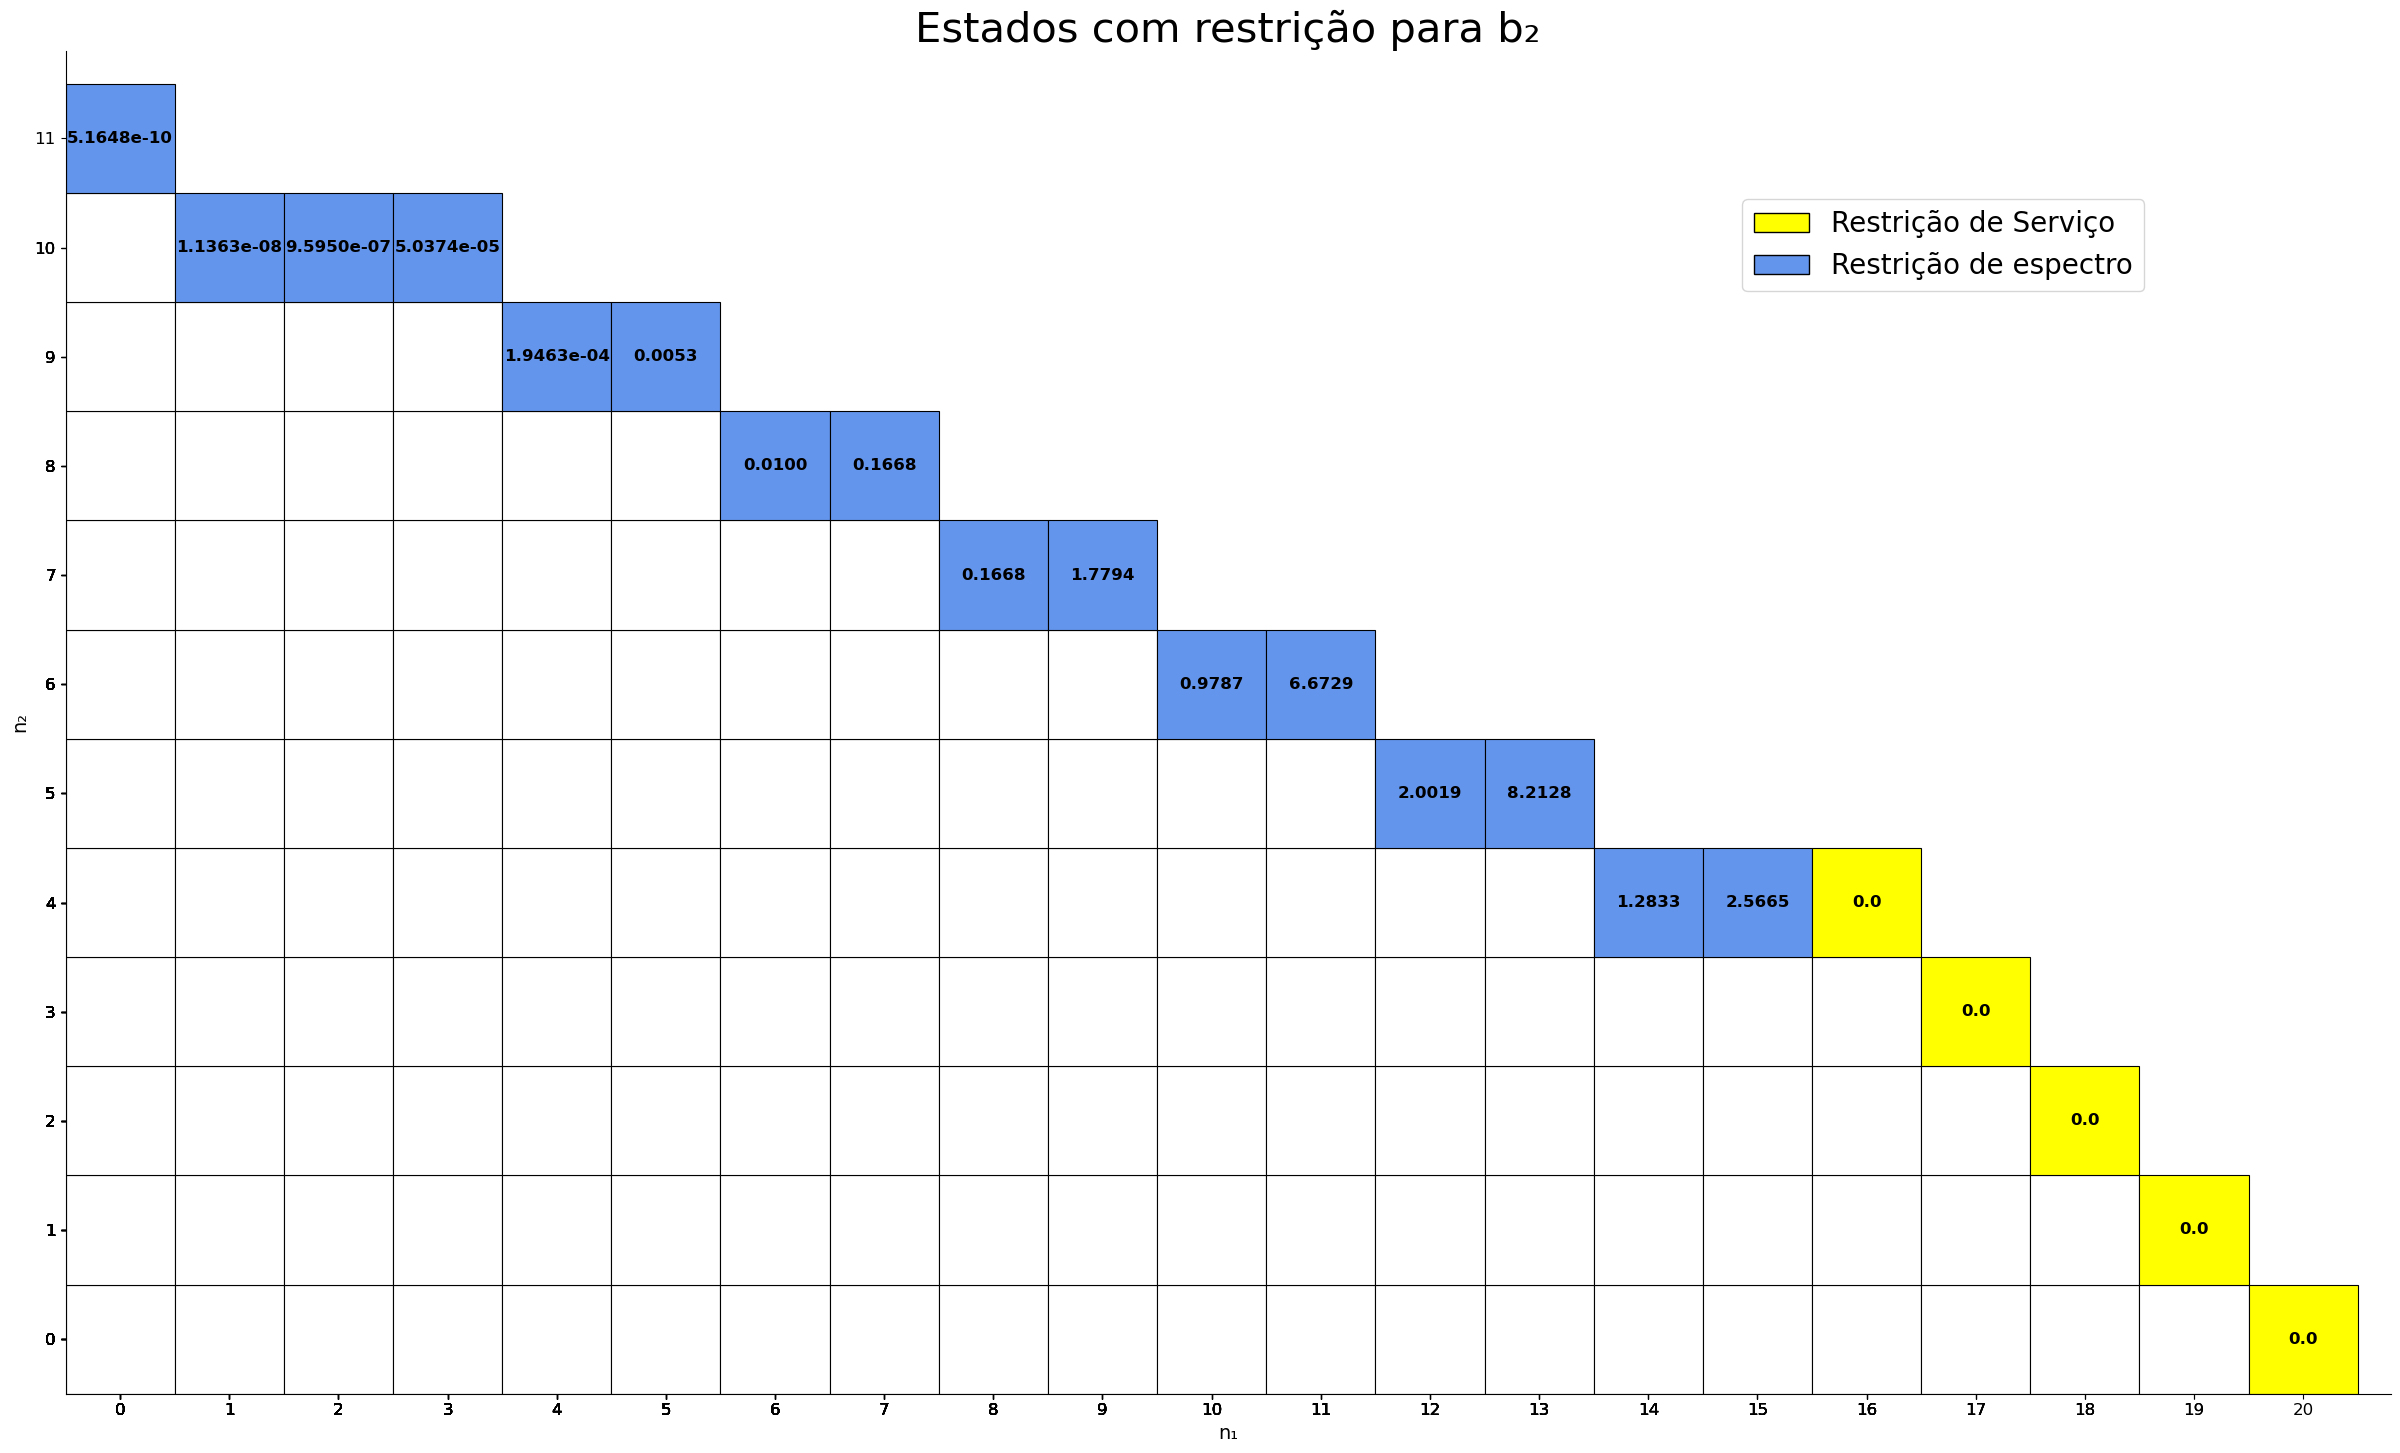

RESULTADOS DE BLOQUEIO

λ = 25.263535392478

β₁ = 16.837393578940
β₂ = 23.844750665591

P(bloqueio b₁) = 66.647020368944%
P(bloqueio b₂) = 94.384061039576%


In [7]:
from matplotlib.patches import Patch

# Criando definição para plotar os estados com restrição
def gerar_tabela_restricao(tipo):
    fig, ax = plt.subplots(figsize=(30,18))
    
    for n1,n2 in estados:
        ocupacao = b1*n1 + b2*n2
        
        if tipo == "b1":
            restricao_servico = (n1+n2 == M)
            restricao_espectro = (b1*(n1+1) + b2*n2 > S)
            
        elif tipo == "b2":
            restricao_servico = (n1+n2 == M)
            restricao_espectro = (b1*n1 + b2*(n2+1) > S)
            
        # Define a COR da restrição
        if restricao_servico:
            cor = "yellow"

        elif restricao_espectro:
            cor = "#6495ED"
            
        else:
            cor = "white"


        # Desenha as células
        rect = patches.Rectangle(
            (n1-0.5,n2-0.5),
            1,
            1,
            linewidth=0.8,
            edgecolor="black",
            facecolor=cor
        )

        ax.add_patch(rect)

        # Mostra o valor nos estados restritos
        if restricao_servico or restricao_espectro:
            valor = produto_estado[(n1, n2)]

            if valor == 0:
                texto = f"{valor}"

            elif valor >= 1e-3:
                texto = f"{valor:.4f}"

            else:
                texto = f"{valor:.4e}"

            ax.text(
                n1,
                n2,
                texto,
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold"
            )
            
    # Eixos
    ax.set_xlabel("n₁",fontsize=14)
    ax.set_ylabel("n₂",fontsize=14)

    ax.set_xticks(n1_validos)
    ax.set_yticks(n2_validos)

    ax.tick_params(labelsize=12)

    ax.set_xlim(-0.5,max(n1_validos)+0.8)
    ax.set_ylim(-0.5,max(n2_validos)+0.8)

    ax.set_aspect("equal")

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Restrições
    if tipo=="b1":
        titulo="Estados com restrição para b₁"
        #fig.savefig(
        #    "restricao_b1_tabela.pdf",
        #    dpi=600,
        #    bbox_inches = "tight",
        #    facecolor = "white"
        #)

    else:
        titulo="Estados com restrição para b₂"
        #fig.savefig(
        #    "Estados com restrição para b₂.pdf",
        #    dpi=600,
        #    bbox_inches= "tight",
        #    facecolor="white"
        #           )
        
    # Caixa de legenda
    legenda = [
        Patch(facecolor = "yellow", edgecolor = "black", label = "Restrição de Serviço" ),
        Patch(facecolor = "#6495ED", edgecolor = "black", label = "Restrição de espectro")
    ]

    ax.legend(
        handles = legenda,
        loc = "upper right",
        bbox_to_anchor = (.9,0.9),
        fontsize = 20,
        frameon = True
    )

    plt.title(titulo,fontsize=30)
    plt.show()

# Gerar as duas imagens
gerar_tabela_restricao("b1")
gerar_tabela_restricao("b2")

# taxa de bloqueio b1 e b2
beta_b1 = 0
beta_b2 = 0

for n1,n2 in estados:
    ocupacao = b1*n1 + b2*n2
    valor = produto_estado[(n1,n2)]

    # Bloqueio b1
    if ocupacao + b1 > S or n1+n2 == M:
        beta_b1 += valor

    # Bloqueio b2
    if ocupacao + b2 > S or n1+n2 == M:
        beta_b2 += valor

# Probabilidade de bloqueio
Pb1 = beta_b1 / lambda_total
Pb2 = beta_b2 / lambda_total

# Resultados
print("RESULTADOS DE BLOQUEIO")
print()
print(f"λ = {lambda_total:.12f}")
print()
print(f"β₁ = {beta_b1:.12f}")
print(f"β₂ = {beta_b2:.12f}")
print()
print(f"P(bloqueio b₁) = {Pb1:.12%}")
print(f"P(bloqueio b₂) = {Pb2:.12%}")

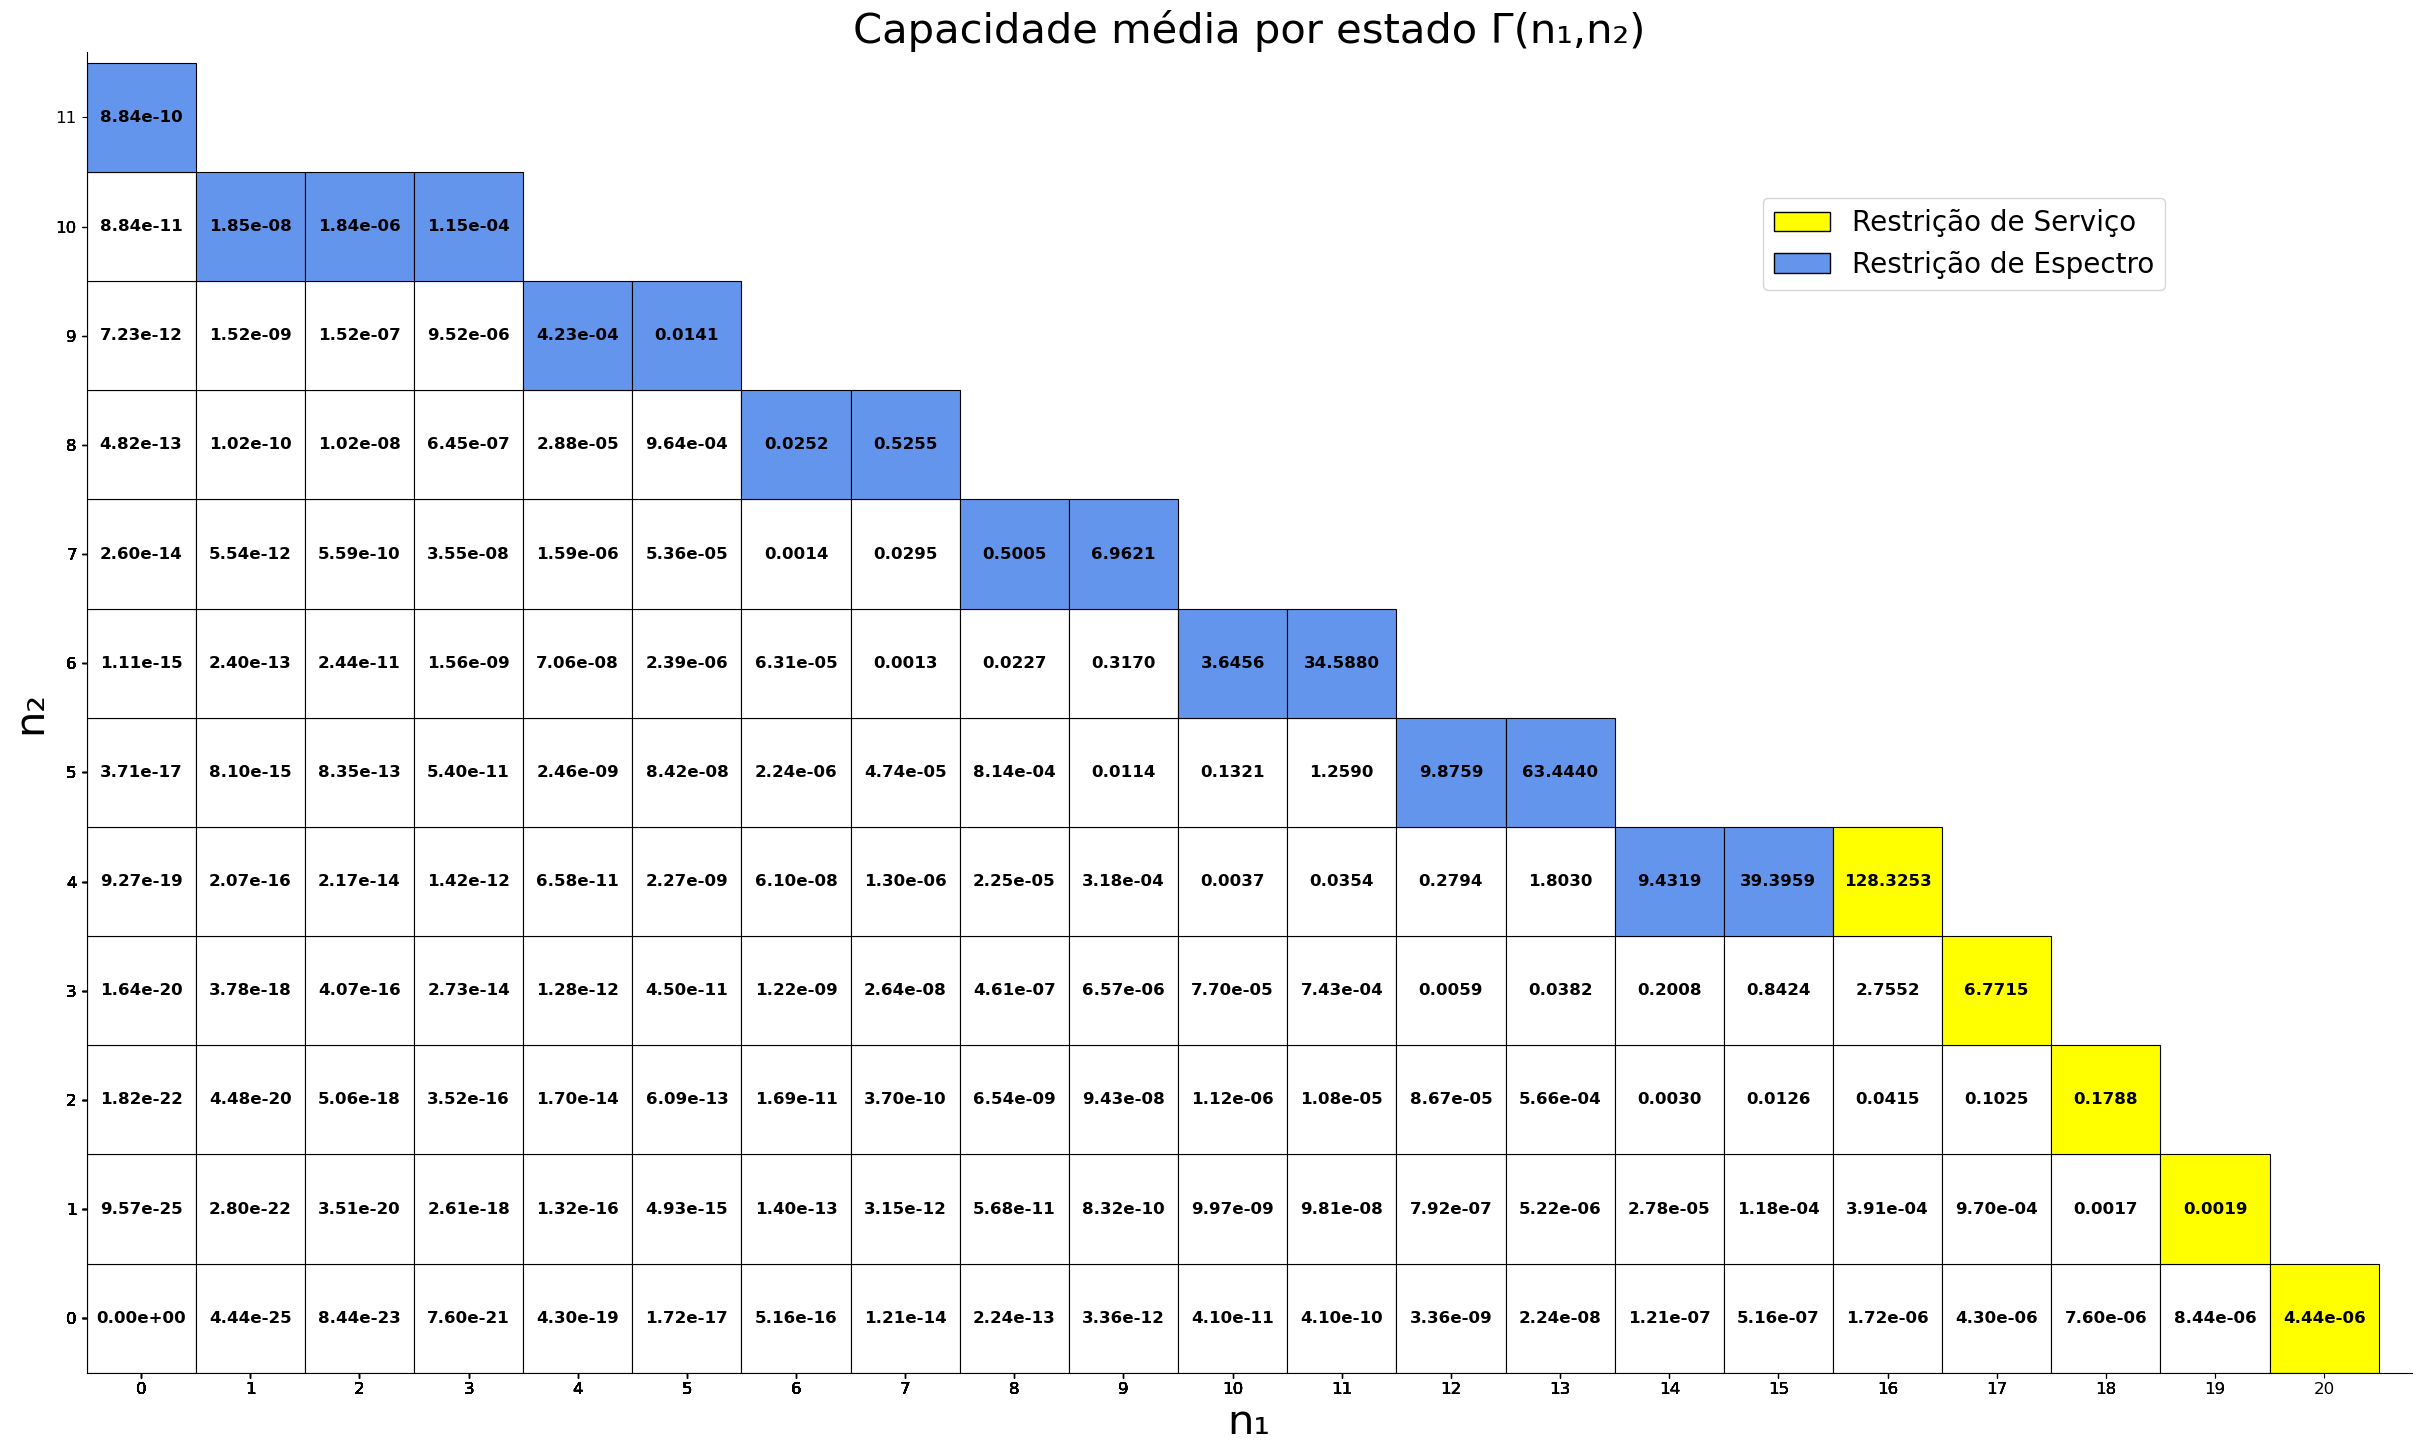

Capacidade média Γ = 311.591870107457 slots
Ocupação média do espectro = Γ / S = 311.591870 / 320 = 0.973725 = 97.37%


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch
from math import comb

# Capacidade média por estado Γ(n1,n2)
capacidade_estado = {}

for n1,n2 in estados:
    capacidade_estado[(n1,n2)] = ((n1*b1 + n2*b2) * prob_estado[(n1,n2)])

# Capacidade média total
Gamma = sum(capacidade_estado.values())

# Tabela
fig, ax = plt.subplots(figsize=(30,18))

# Restrições
for n1,n2 in estados:
    cap_max_fonte = (n1+n2 == M)

    restricao = (
        b1*(n1+1) + b2*n2 > S
        or
        b1*n1 + b2*(n2+1) > S
    )

    rect = patches.Rectangle(
        (n1-0.5,n2-0.5),
        1,
        1,
        linewidth=0.8,
        edgecolor='black',
        facecolor=(
            'yellow' if cap_max_fonte
            else "#6495ED" if restricao
            else 'white'
        )
    )

    ax.add_patch(rect)

    valor = capacidade_estado[(n1,n2)]

    # Texto
    if valor >= 1e-3:
        texto = f"{valor:.4f}"
        
    else:
        texto = f"{valor:.2e}"

    ax.text(
        n1,
        n2,
        texto,
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold'
    )

# Configuração dos eixos
ax.set_xlabel("n₁",fontsize=30)
ax.set_ylabel("n₂",fontsize=30)

ax.set_xticks(n1_validos)
ax.set_yticks(n2_validos)

ax.tick_params(axis='both',labelsize=12)

ax.set_xlim(-0.5,max(n1_validos)+0.8)
ax.set_ylim(-0.5,max(n2_validos)+0.6)

ax.set_aspect('equal')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Caixa de legenda
legenda = [
    Patch(facecolor = "yellow", edgecolor = "black", label = "Restrição de Serviço"),
    Patch(facecolor = "#6495ED", edgecolor = "black", label = "Restrição de Espectro")
]

ax.legend(
    handles = legenda,
    loc = "upper right",
    bbox_to_anchor = (0.9,0.9),
    fontsize = 20
)

# Título
plt.title(
    "Capacidade média por estado Γ(n₁,n₂)",
    fontsize=30
)

#fig.savefig(
#    "Capacidade média por estado Γ(n₁,n₂).pdf",
#    dpi=600,
#    bbox_inches="tight",
#    facecolor="white"
#)

plt.show()

# Resultados
print(f"Capacidade média Γ = {Gamma:.12f} slots")
print(f"Ocupação média do espectro = Γ / S = {Gamma:.6f} / {S} = {(Gamma/S):.6f} = {(Gamma/S):.2%}")
